In [1]:
import os
import shutil
import random

# Paths
base_path = 'C:/Users/spiri/Downloads/Brain-Tumor-Detection-Using-SVM/'
train_path = os.path.join(base_path, "Training")
val_path = os.path.join(base_path, "Validation")

# Create val folder
if not os.path.exists(val_path):
    os.makedirs(val_path)

# Classes
classes = os.listdir(train_path)

split_ratio = 0.2  # 20% for validation

for cls in classes:
    train_cls_path = os.path.join(train_path, cls)
    val_cls_path = os.path.join(val_path, cls)

    os.makedirs(val_cls_path, exist_ok=True)

    images = os.listdir(train_cls_path)
    random.shuffle(images)

    split_size = int(len(images) * split_ratio)
    val_images = images[:split_size]

    for img in val_images:
        src = os.path.join(train_cls_path, img)
        dst = os.path.join(val_cls_path, img)

        shutil.move(src, dst)   # move file

In [2]:
import sys
!{sys.executable} -m pip install imageio
import imageio


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import numpy as np
import pandas as pd
import pathlib

In [4]:
# Exploring dataset 
base_dir = 'C:/Users/spiri/Downloads/Brain-Tumor-Detection-Using-SVM/'

train_notumor_dir = base_dir+'Training/no_tumor/'
train_glioma_dir = base_dir+'Training/glioma_tumor/'
train_meningioma_dir = base_dir+'Training/meningioma_tumor/'
train_pituitary_dir = base_dir+'Training/pituitary_tumor/'


test_notumor_dir = base_dir+'Testing/no_tumor/'
test_glioma_dir = base_dir+'Testing/glioma_tumor/'
test_meningioma_dir = base_dir+'Testing/meningioma_tumor/'
test_pituitary_dir = base_dir+'Testing/pituitary_tumor/'

val_notumor_dir= base_dir+'Validation/no_tumor/'
val_glioma_dir= base_dir+'Validation/glioma_tumor/'
val_meningioma_dir= base_dir+'Validation/meningioma_tumor/'
val_pituitary_dir= base_dir+'Validation/pituitary_tumor/'

train_notumor = [train_notumor_dir+"{}".format(i) for i in os.listdir(train_notumor_dir) ]
train_glioma = [train_glioma_dir+"{}".format(i) for i in os.listdir(train_glioma_dir) ]
train_meningioma = [train_meningioma_dir+"{}".format(i) for i in os.listdir(train_meningioma_dir) ]
train_pituitary = [train_pituitary_dir+"{}".format(i) for i in os.listdir(train_pituitary_dir) ]

test_notumor = [test_notumor_dir+"{}".format(i) for i in os.listdir(test_notumor_dir) ]
test_glioma = [test_glioma_dir+"{}".format(i) for i in os.listdir(test_glioma_dir) ]
test_meningioma = [test_meningioma_dir+"{}".format(i) for i in os.listdir(test_meningioma_dir) ]
test_pituitary = [test_pituitary_dir+"{}".format(i) for i in os.listdir(test_pituitary_dir) ]

val_notumor = [val_notumor_dir+"{}".format(i) for i in os.listdir(val_notumor_dir) ]
val_glioma = [val_glioma_dir+"{}".format(i) for i in os.listdir(val_glioma_dir) ]
val_meningioma = [val_meningioma_dir+"{}".format(i) for i in os.listdir(val_meningioma_dir) ]
val_pituitary = [val_pituitary_dir+"{}".format(i) for i in os.listdir(val_pituitary_dir) ]



print ("Total images:",len(train_notumor+train_glioma+train_meningioma+train_pituitary+test_notumor+test_glioma+test_meningioma+test_pituitary+val_notumor+val_glioma+val_meningioma+val_pituitary))
print ("Total no tumor images:",len(train_notumor+test_notumor+val_notumor))
print ("Total glioma_tumor images:",len(train_glioma+test_glioma+val_glioma))
print ("Total meningioma_tumor images:",len(train_meningioma+test_meningioma+val_meningioma))
print ("Total pituitary_tumor images:",len(train_pituitary+test_pituitary+val_pituitary))


Total images: 3264
Total no tumor images: 500
Total glioma_tumor images: 926
Total meningioma_tumor images: 937
Total pituitary_tumor images: 901


In [5]:
# Dataset Splitting (train 80% , test 20% )


no_tumor=train_notumor+test_notumor+val_notumor
pituitary_tumor=train_pituitary+test_pituitary+val_pituitary
glioma_tumor=train_glioma+test_glioma+val_glioma
meningioma_tumor=train_meningioma+test_meningioma+val_meningioma


# Spliting dataset in train set,test set and validation set.
# TRAIN (80%)
train_imgs = (
    no_tumor[:400] +
    glioma_tumor[:741] +
    meningioma_tumor[:750] +
    pituitary_tumor[:721]
)

# VALIDATION (15%)
val_imgs = (
    no_tumor[400:475] +
    glioma_tumor[741:880] +
    meningioma_tumor[750:890] +
    pituitary_tumor[721:856]
)

# TEST (5%)
test_imgs = (
    no_tumor[475:] +
    glioma_tumor[880:] +
    meningioma_tumor[890:] +
    pituitary_tumor[856:]
)

print("Total Train Images %s" 
      % (len(train_imgs)))
print("Total Test Images %s "
      % (len(test_imgs)))
print("Total Val Images %s "
      % (len(val_imgs)))




import random

random.shuffle(train_imgs)
random.shuffle(test_imgs)
random.shuffle(val_images)


Total Train Images 2612
Total Test Images 163 
Total Val Images 489 


In [14]:
#showing a file name from test set
print(test_imgs[5])

C:/Users/spiri/Downloads/Brain-Tumor-Detection-Using-SVM/Validation/meningioma_tumor/m3 (240).jpg


In [6]:
import cv2
img_size = 224

def preprocess_image(image_list):
    
    X = [] # images
    y = [] #labels (0 for Normal or 1 for Pneumonia)
    count=0
    
    for image in image_list:
        
        try:

            img = cv2.imread(image,cv2.IMREAD_GRAYSCALE)
            
            img=cv2.resize(img,(img_size,img_size),interpolation=cv2.INTER_CUBIC)
            
            #convert image to 2D to 3D 
            img = np.dstack([img, img, img])
            
            #convrt greyscale image to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Normalalize Image
            img = img.astype(np.float32)/255.
            
            count=count+1

            X.append(img) 
            
            
        except:
            continue
        #get the labels 
        if 'no_tumor' in image:
            y.append(0)
            
        elif 'glioma_tumor' in image:
            y.append(1)
        
        elif 'pituitary_tumor' in image:
            y.append(2)
            
        elif 'meningioma_tumor' in image:
            y.append(3)
            
    
    return X, y

In [8]:
X, y = preprocess_image(train_imgs)

In [9]:
# Check all the images getting labels or not
arr=y	
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)


Unique Values :  [0 1 2 3]
Occurrence Count :  [400 741 721 750]


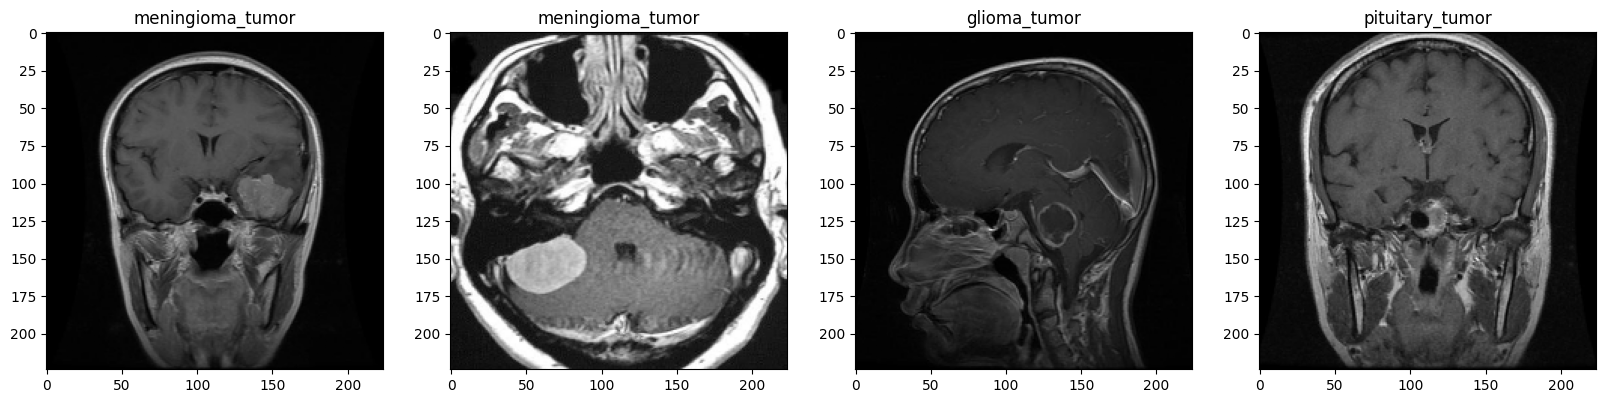

In [10]:
# Display some images from train set

import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (y[i]==0):
        a.set_title('no_tumor')
    elif (y[i]==1):
        a.set_title('glioma_tumor')
    elif (y[i]==2):
        a.set_title('pituitary_tumor')
    else:
        a.set_title('meningioma_tumor')    
    plt.imshow(X[i])
    k=k+1;
    


In [13]:
# get the labels for test set

P, t = preprocess_image(test_imgs)

In [14]:
arr=t	
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1 2 3]
Occurrence Count :  [25 46 45 47]


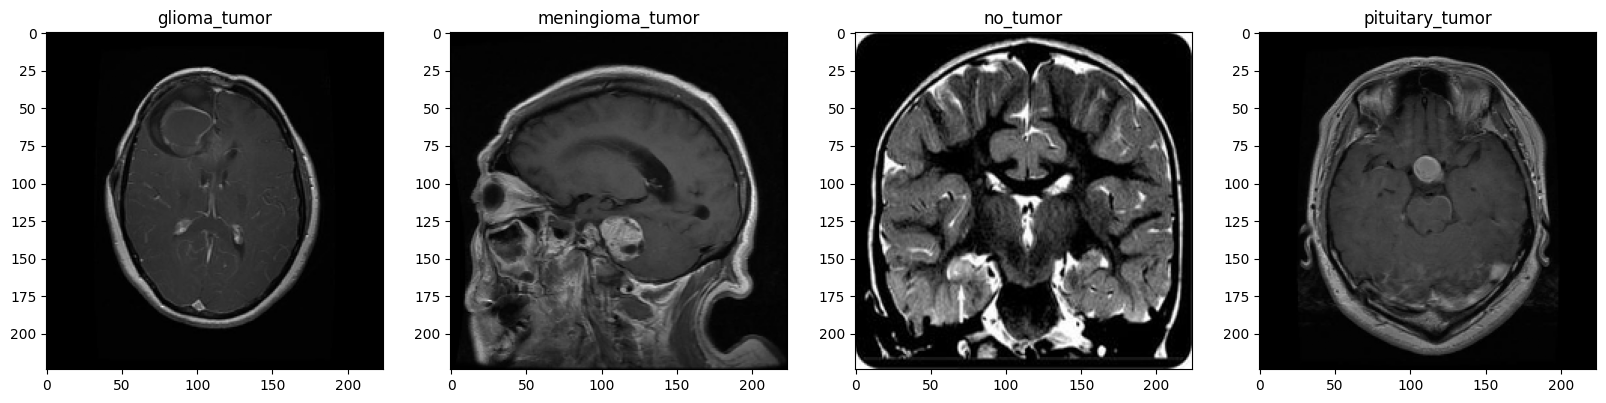

In [21]:
# now displaying some images from test set


import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    
    if (t[i]==0):
        a.set_title('no_tumor')
    elif (t[i]==1):
        a.set_title('glioma_tumor')
    elif (t[i]==2):
        a.set_title('pituitary_tumor')
    else:
        a.set_title('meningioma_tumor')
        
    plt.imshow(P[i])
    k=k+1;

In [15]:
K, m = preprocess_image(val_imgs)

In [16]:

arr=m

 
# Get a tuple of unique values & their frequency in numpy array
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1 2 3]
Occurrence Count :  [ 75 139 135 140]


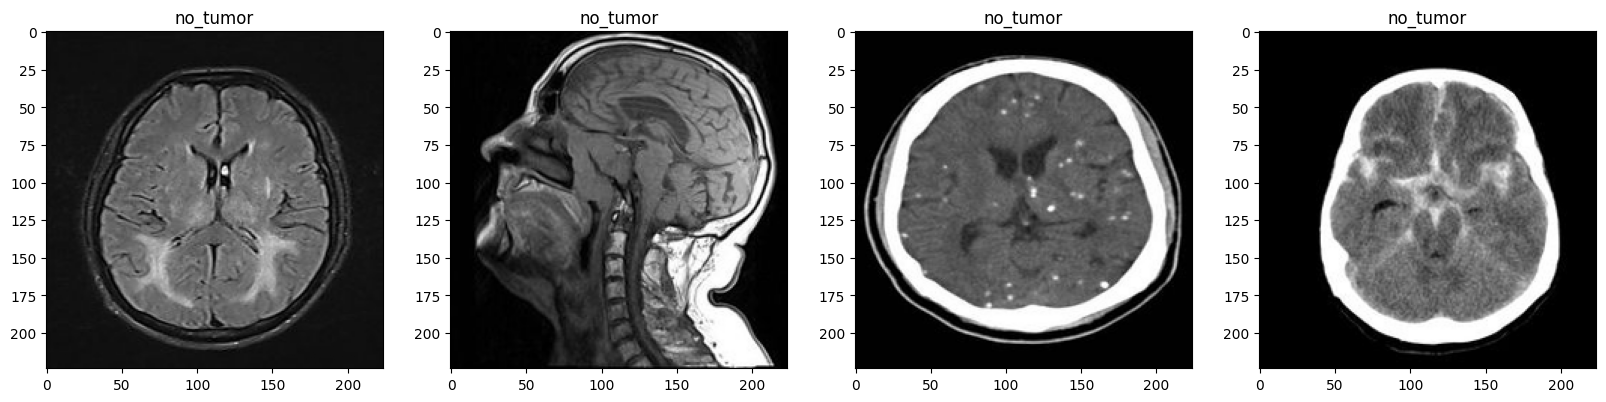

In [25]:
# now displaying some images from val set


import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    
    if (m[i]==0):
        a.set_title('no_tumor')
    elif (m[i]==1):
        a.set_title('glioma_tumor')
    elif (m[i]==2):
        a.set_title('pituitary_tumor')
    else:
        a.set_title('meningioma_tumor')
        
    plt.imshow(K[i])
    k=k+1;

In [11]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.6325), 1: np.float64(0.8812415654520918), 2: np.float64(0.9056865464632455), 3: np.float64(0.8706666666666667)}


In [17]:
import seaborn as sns
import gc

train_imgs = no_tumor[:400]+ pituitary_tumor[:721]+ glioma_tumor[:741]+meningioma_tumor[:750]
del train_imgs
gc.collect()

X_train = np.array(X)
y_train = np.array(y)
X_test = np.array(P)
y_test = np.array(t)
X_val=np.array(K)
y_val=np.array(m)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.shape)
print(y_val.shape)



(2612, 224, 224, 3)
(2612,)
(163, 224, 224, 3)
(163,)
(489, 224, 224, 3)
(489,)


In [18]:
# clear memory
del X
del y
gc.collect()

#get the length of the train and validation data
ntrain = len(X_train)
nval = len(X_val)

batch_size = 32

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(  rotation_range=7,
                                     width_shift_range=0.05,
                                     height_shift_range=0.05,
                                     shear_range=0.2,
                                     zoom_range=0.45,
                                     horizontal_flip=True)
                                   
val_datagen = ImageDataGenerator(zoom_range=0.45)  

In [20]:
#Create the image generators
train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size)
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size)

In [21]:
# Set image Size
img_size =224

In [22]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

img_size = 224   # MobileNet standard

# Load pretrained model
base_model = MobileNet(
    weights='imagenet',   # ✅ transfer learning
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)   # helps prevent overfitting
x = Dense(128, activation='relu')(x)

# Output layer (4 classes)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights   # 👈 from your earlier code
)

c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 58s 642ms/step - accuracy: 0.4702 - loss: 1.3474 - val_accuracy: 0.7526 - val_loss: 0.5668
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 651ms/step - accuracy: 0.7184 - loss: 0.7015 - val_accuracy: 0.8200 - val_loss: 0.4523
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 52s 634ms/step - accuracy: 0.7440 - loss: 0.6459 - val_accuracy: 0.8098 - val_loss: 0.4819
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 621ms/step - accuracy: 0.7660 - loss: 0.5732 - val_accuracy: 0.8200 - val_loss: 0.4430
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 622ms/step - accuracy: 0.7587 - loss: 0.5890 - val_accuracy: 0.8384 - val_loss: 0.4402
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 619ms/step - accuracy: 0.7850 - loss: 0.5297 - val_accuracy: 0.8609 - val_loss: 0.3813
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 621ms/step - accuracy: 0.7875 - loss: 0.5158 - val_accuracy: 0.8466 - val_loss: 0.4123
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 651ms/step - accuracy: 0.8005 - loss: 0.5153 - val_accu

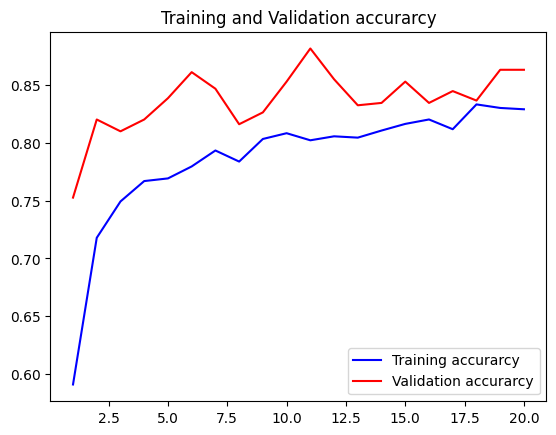

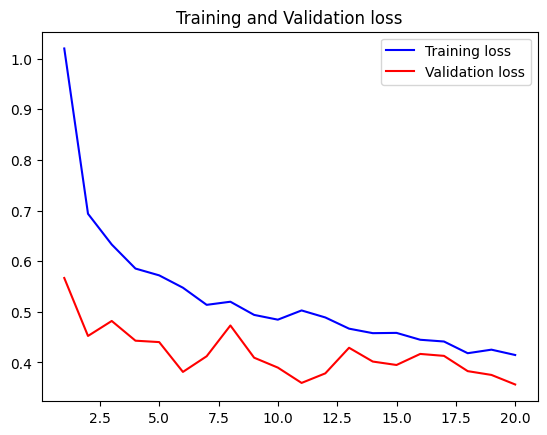

In [24]:
# Lets plot the train and val curve
# Get the details form the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='Training accurarcy')
plt.plot(epochs, val_acc, 'r', label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

In [1]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = model.predict(val_generator)
y_pred_classes = y_pred.argmax(axis=1)

# True labels
y_true = val_generator.history

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# Classification Report
print(classification_report(y_true, y_pred_classes))

NameError: name 'model' is not defined